# ----STUDENT PERFORMANCE EDA----

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Students Performance in Exams dataset

In [3]:
url = "https://raw.githubusercontent.com/NadavKiani/Students-Performance-in-Exams/master/StudentsPerformance.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### To inspect dimensions 

In [5]:
df.shape

(1000, 8)

### To check Column data types 

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### To check Summary statistics 

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### To check total missing values

In [15]:
df.isnull().sum()
# Here in this data there is no missing values. If there is any missing values then we can either 
#remove the whole row or we can use statistical method to remove the misiing values

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### To check Duplicates values in the data

In [16]:
df.duplicated().sum()
#Here there is agian no duplicates value. If there any dupliactes row we can delete it by
#(df.drop_duplicates()).It will delete all the duplicates row


np.int64(0)

### *  ---- Segregate Numerical and Categorical Features ----

In [29]:
numerical_features = [feature for feature in df.columns if df[feature].dtype !='str']
categorical_features = [feature for feature in df.columns if df[feature].dtype =='str']
print("Numerical Features : ", numerical_features)
print("Categorical Features : ",categorical_features)

Numerical Features :  ['math score', 'reading score', 'writing score']
Categorical Features :  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [26]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

### Feature Engineering

In [30]:
df['Total_Marks'] = df['math score']+df['reading score']+df['writing score']
df['average']=df['Total_Marks']/3
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Marks,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


### Visualizations:----
Subplot 1: Overall Average Score vs Gender Sub-groups

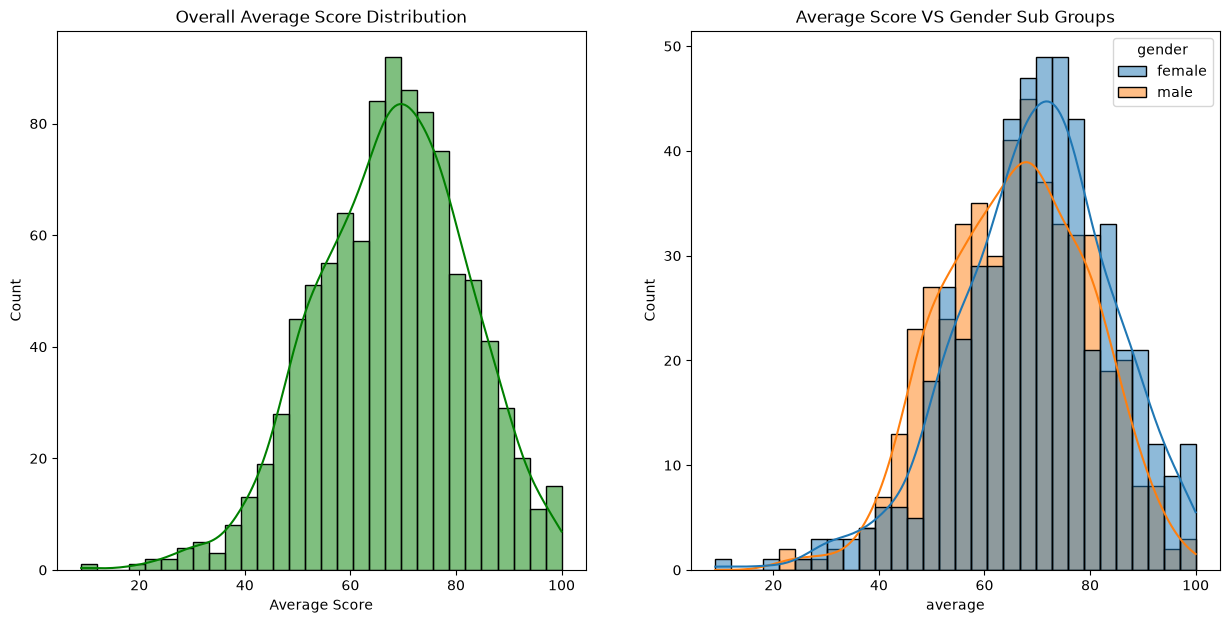

In [39]:
plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
sns.histplot(data=df,x='average',bins=30,color='g',kde=True)
plt.title('Overall Average Score Distribution')
plt.xlabel('Average Score')

plt.subplot(1 , 2 , 2)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='gender')
plt.title('Average Score VS Gender Sub Groups')
plt.show()

### Subplot 2: Multi-panel Lunch Impact Analysis

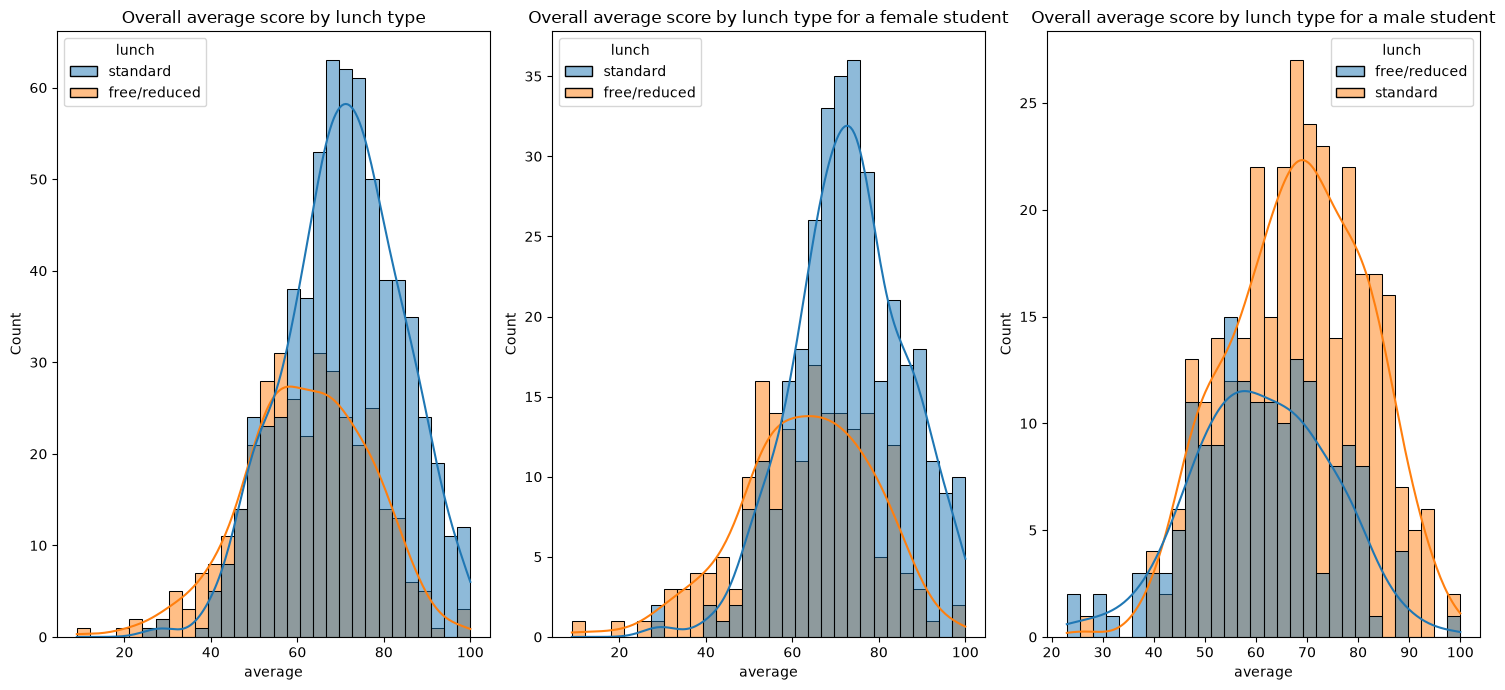

In [51]:
plt.figure(figsize=(15,7))

plt.subplot(1,3,1)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='lunch')
plt.title('Overall average score by lunch type')

plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='female'],x='average',bins=30,kde=True,hue='lunch')
plt.title('Overall average score by lunch type for a female student')

plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='male'],x='average',bins=30,kde=True,hue='lunch')
plt.title('Overall average score by lunch type for a male student')

plt.tight_layout()
plt.show()

## Key Insight: Students receiving standard lunch consistently outperform students receiving free/reduced lunch, regardless of gender.

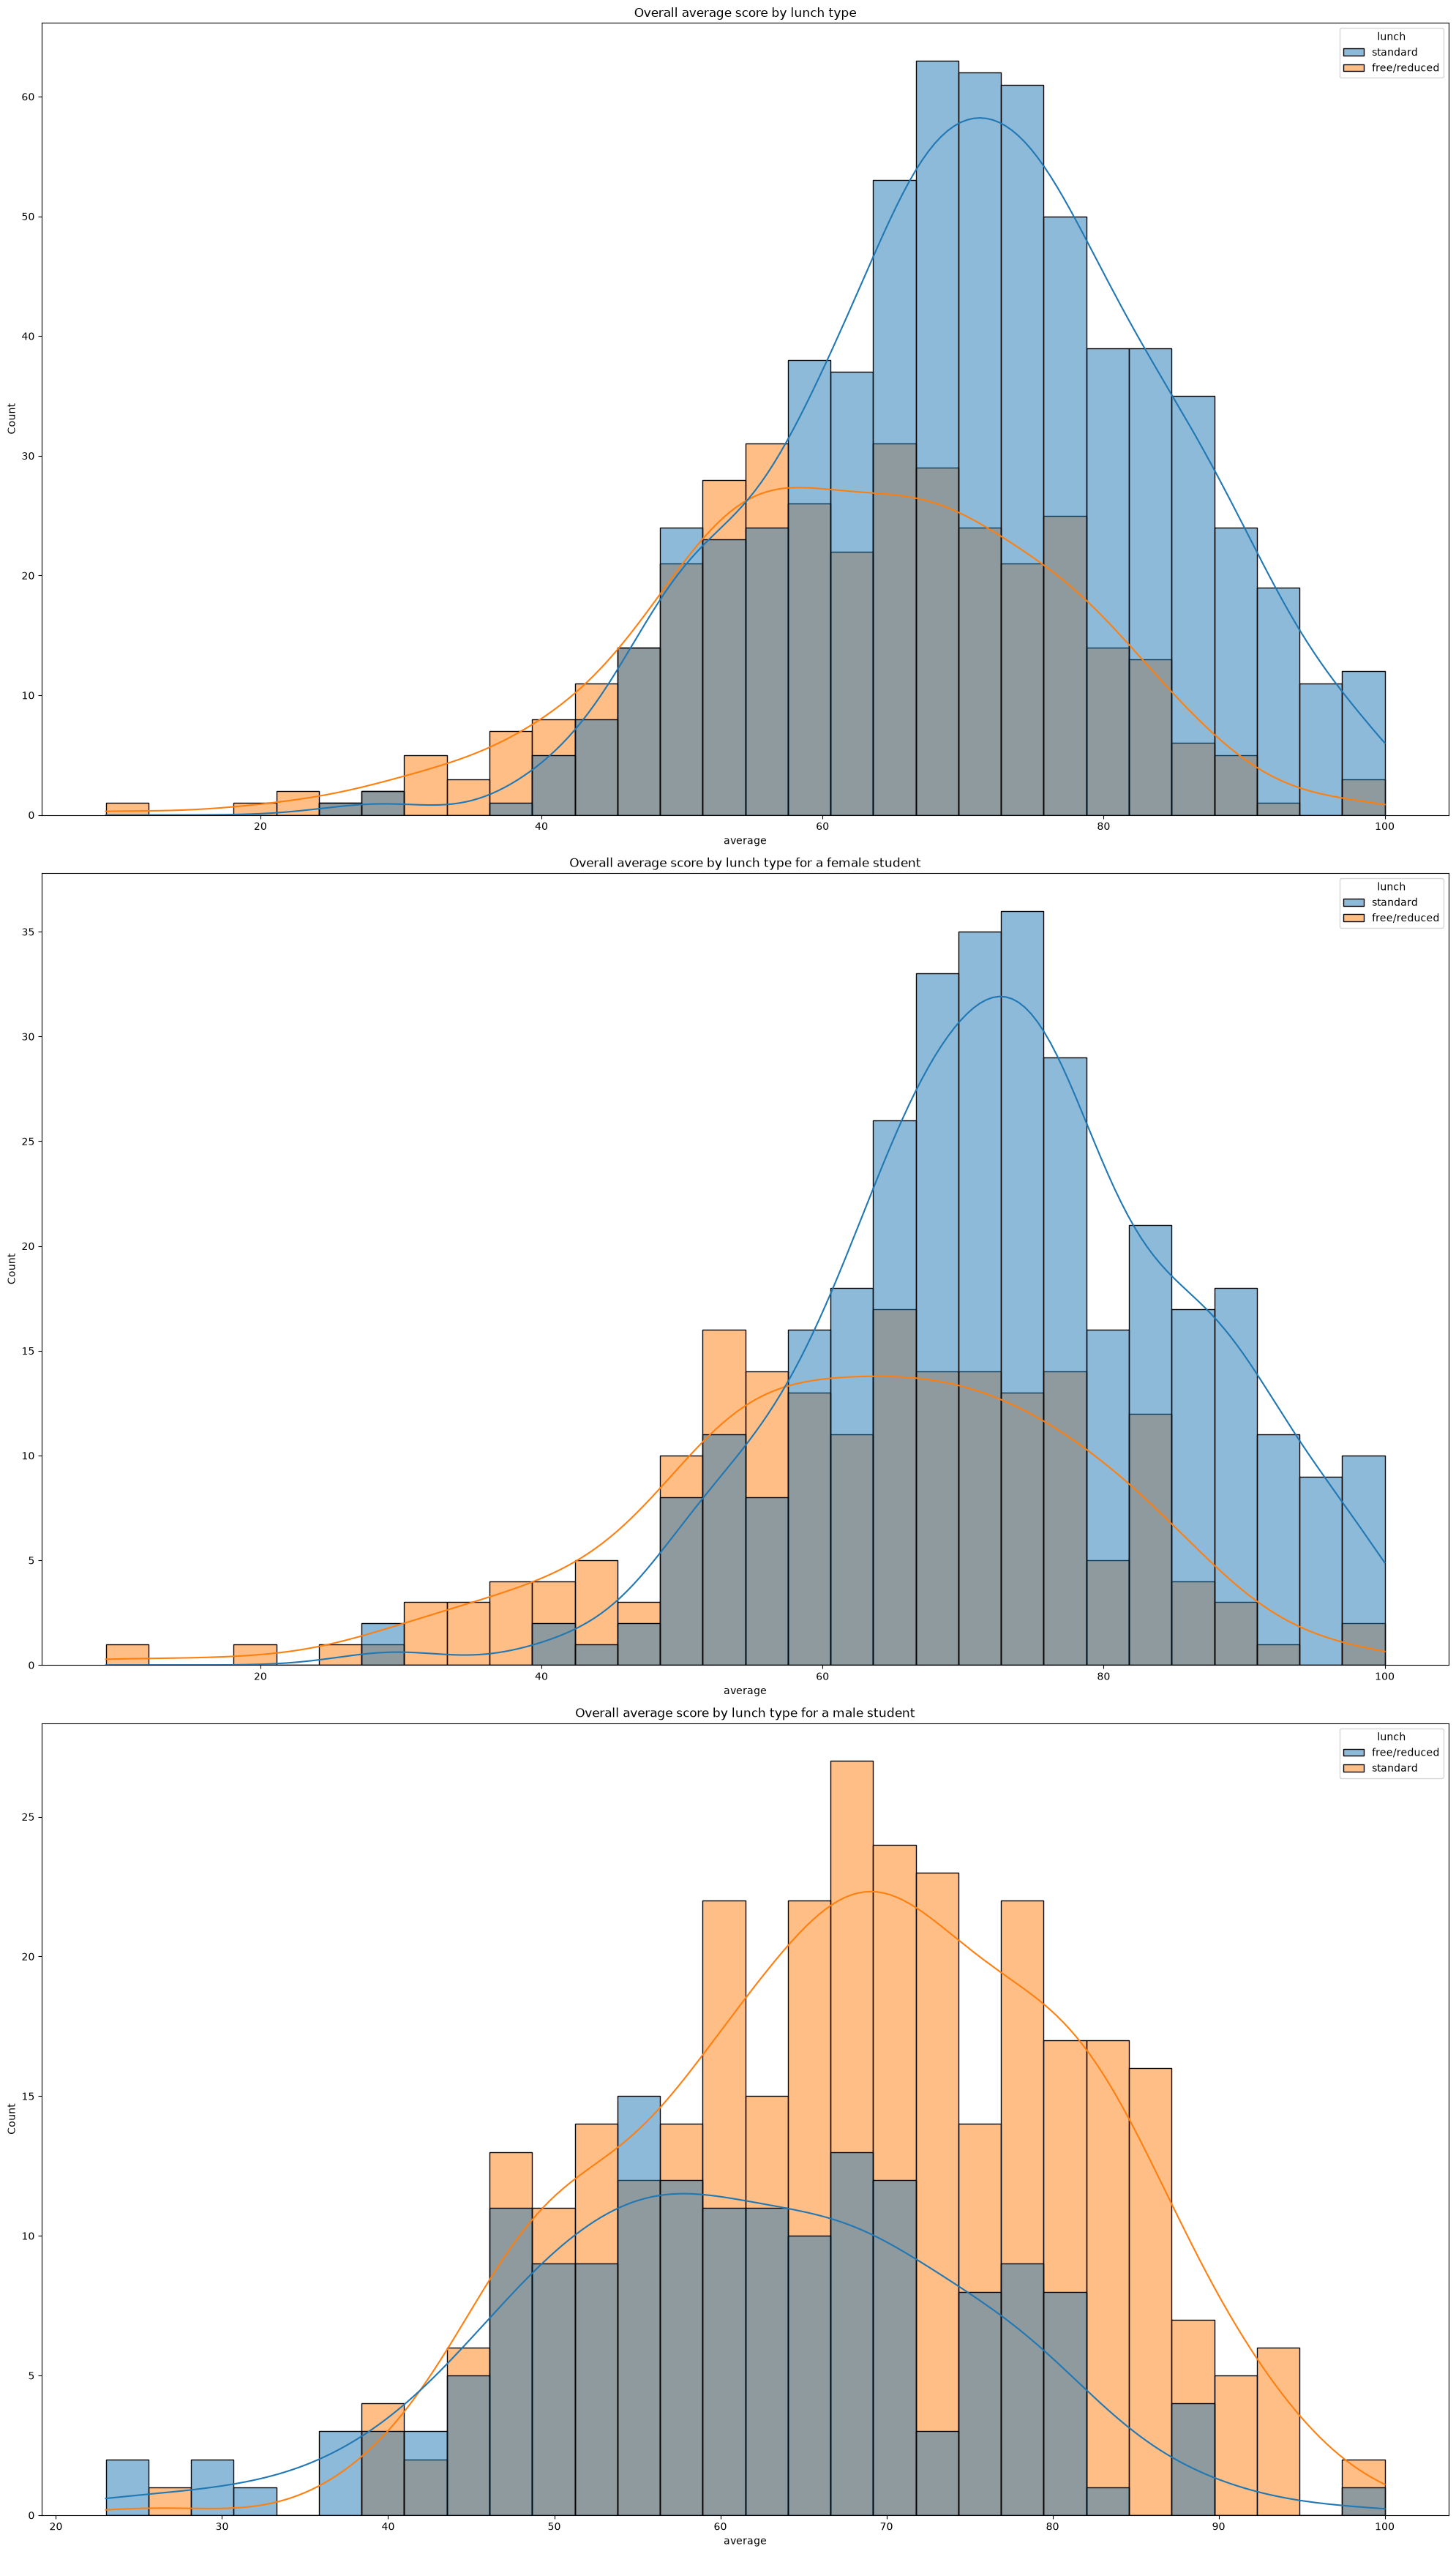

In [58]:
plt.figure(figsize=(20,35))

plt.subplot(3,1,1)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='lunch')
plt.title('Overall average score by lunch type')

plt.subplot(3,1,2)
sns.histplot(data=df[df['gender']=='female'],x='average',bins=30,kde=True,hue='lunch')
plt.title('Overall average score by lunch type for a female student')

plt.subplot(3,1,3)
sns.histplot(data=df[df['gender']=='male'],x='average',bins=30,kde=True,hue='lunch')
plt.title('Overall average score by lunch type for a male student')

plt.tight_layout()
plt.show()